In [2]:
# baseline_random_forest_json.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset from JSON
# Replace with your actual file path, e.g. "standardised.json"
data = pd.read_json(r"E:\RSXS\Study\project\ParticulateMatterApp\data\ML\standardised_airqo.json")

# Quick check
print("Dataset head:\n", data.head())

Dataset head:
                        hour   pm25  temperature  humidity  \
0  2026-07-03T06:00:00.000Z  18.35        24.47     73.09   
1  2026-07-03T07:00:00.000Z  46.08        27.35     66.01   
2  2026-07-03T08:00:00.000Z  27.90        32.13     53.95   
3  2026-07-03T09:00:00.000Z  24.18        34.57     45.50   
4  2026-07-03T10:00:00.000Z  16.86        37.11     39.59   

                            site  
0  Civic Centre, Kampala Central  
1  Civic Centre, Kampala Central  
2  Civic Centre, Kampala Central  
3  Civic Centre, Kampala Central  
4  Civic Centre, Kampala Central  


Baseline Model Performance:
RMSE: 31.94
R² Score: 0.02


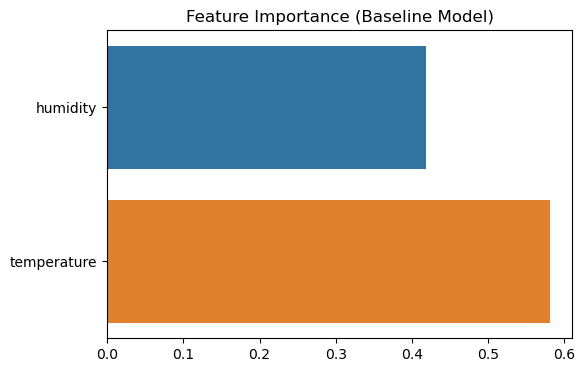

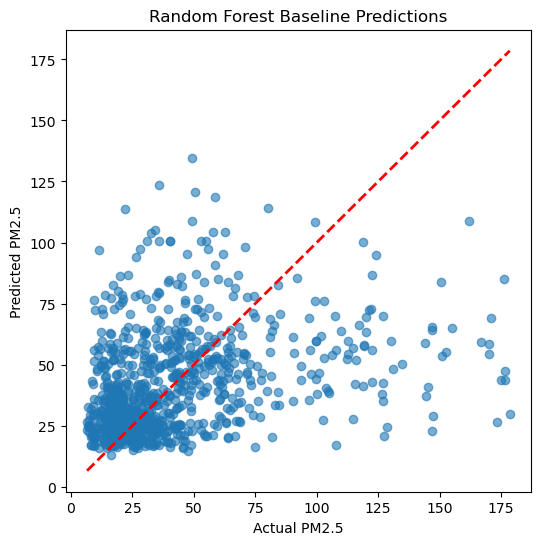

In [13]:
# 2. Define features and target
# Assuming JSON has keys/columns: humidity, temperature, pm2_5

# Drop rows with NaN values in humidity, temperature, or pm2_5
data = data.dropna(subset=["humidity", "temperature", "pm25"])

X = data[["humidity", "temperature"]]
y = data["pm25"]

X = data[["humidity", "temperature"]]
y = data["pm25"]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Initialize Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,       # number of trees
    max_depth=None,         # let trees expand fully
    random_state=42,
    n_jobs=-1               # use all cores for speed
)

# 5. Train model
rf_model.fit(X_train, y_train)

# 6. Predictions
y_pred = rf_model.predict(X_test)

# 7. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Baseline Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 8. Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Baseline Model)")
plt.show()

# 9. Scatter plot of predictions vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest Baseline Predictions")
plt.show()
